# Laboratorio 4 — Parte 2
## Análisis de modelos usando datos geoespaciales

**CC3084 — Data Science · Universidad del Valle de Guatemala**

Este notebook construye, a partir de los rásteres obtenidos en la **Parte I**
del laboratorio (índices `NDVI`, `NDWI` e índice de cianobacteria /
chlorophyll-a estimado para los lagos de **Atitlán** y **Amatitlán**), un
conjunto de datos tabular apto para Machine Learning, define la variable
respuesta binaria de presencia de cianobacteria, y selecciona/construye las
variables predictoras que se usarán en la Parte 2 (Ejercicios 4 en adelante).

Este avance cubre los **Ejercicios 1, 2 y 3** del enunciado (preparación de
datos, variable respuesta y variables predictoras).

**Requisito:** este notebook asume que ya se ejecutó la Parte I y que existe,
en el mismo directorio del proyecto, la carpeta `data/` con la siguiente
estructura (generada por `Lab4_datos_geoespacial.ipynb`):

```
data/
├── cyano/
│   ├── amatitlan/<fecha>.npy      # raster de chlorophyll-a (µg/L), 1 archivo por fecha
│   └── atitlan/<fecha>.npy
└── indices/
    ├── amatitlan/{ndvi.nc, ndwi.nc}
    └── atitlan/{ndvi.nc, ndwi.nc}
```

y los archivos `lago_amatitlan.geojson` y `lago_atitlan.geojson` con el
contorno de cada lago (usados en la Parte I).


## 0. Configuración del entorno

In [22]:
pip install rioxarray geopandas shapely seaborn scipy netCDF4


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray  # habilita el accessor .rio sobre xarray
import geopandas as gpd
from shapely.geometry import Point

from scipy.interpolate import griddata

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


### Parámetros del laboratorio

Se reutilizan exactamente las mismas coordenadas de los *bounding boxes* y las
mismas 11 fechas oficiales por lago que se usaron en la Parte I, para
garantizar que el conjunto de datos de la Parte 2 sea consistente con el
análisis exploratorio ya realizado.

In [24]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}

lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799
}

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
    "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
    "2026-04-13", "2026-04-28", "2026-06-19"
]

fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-11-19",
    "2026-01-05", "2026-01-30", "2026-02-04", "2026-03-26",
    "2026-04-10", "2026-04-25", "2026-06-16"
]

LAGOS_BBOX = {"Amatitlán": lago_amatitlan, "Atitlán": lago_atitlan}
LAGOS_FECHAS = {"Amatitlán": fechas_amatitlan, "Atitlán": fechas_atitlan}
LAGOS_SLUG = {"Amatitlán": "amatitlan", "Atitlán": "atitlan"}

RUTA_DATA = "data"
CRS_GEOGRAFICO = "EPSG:4326"
CRS_METRICO = "EPSG:32615"  # WGS 84 / UTM zona 15N — usado también en la validación espacial (Ejercicio 6)


## 1. Preparación de los datos para Machine Learning

### 1.1 y 1.2 — Construcción del conjunto de datos geoespacial

**Estrategia general.** El raster de cianobacteria (`data/cyano/<lago>/<fecha>.npy`)
es la fuente de la variable respuesta: fue calculado por Sentinel Hub sobre una
grilla regular de latitud/longitud definida por el *bounding box* del lago y
una resolución de 20 m, y **ya trae `NaN` en todo píxel que no es agua**
(la clasificación agua/no-agua ocurre dentro del *evalscript*, combinando
`MNDWI`, `NDWI`, `AWEI` y `NDVI`). Por lo tanto, esta grilla se usa como
**grilla de referencia**: solo los píxeles con un valor válido de
cianobacteria se consideran observaciones geográficas válidas dentro del
lago.

Los índices `NDVI` y `NDWI`, en cambio, se descargaron por separado vía
`openEO` como `NetCDF` y pueden estar en una grilla espacial distinta (otra
resolución nativa y, potencialmente, otro sistema de referencia de
coordenadas). Para poder unir ambas fuentes en una sola tabla:

1. Se abre cada `NetCDF`, se detecta su CRS con `rioxarray` y, si no está en
   coordenadas geográficas (`EPSG:4326`), se reproyecta.
2. Para cada fecha, se interpola (`nearest neighbor`) el valor de `NDVI` y
   `NDWI` más cercano a cada píxel válido de la grilla de cianobacteria.
   Se usa el vecino más cercano — y no una interpolación bilineal — porque
   estamos re-muestreando índices espectrales ya derivados y queremos
   conservar valores realmente observados en un píxel cercano, en vez de
   generar valores sintéticos por interpolación lineal entre píxeles con
   posible nubosidad distinta.
3. Cada fila final del conjunto de datos representa **una observación
   geográfica (un píxel de agua) en una fecha y un lago determinados**, con
   sus coordenadas (`lat`, `lon`), el índice de cianobacteria (chlorophyll-a
   estimado, en µg/L) y los índices espectrales `NDVI`/`NDWI` correspondientes.


In [25]:
def coords_desde_bbox(bbox, shape):
    '''Genera grids 2D de lat/lon para un raster regular alineado al bbox.
    Convención: fila 0 = borde norte, columna 0 = borde oeste (estándar en
    rasters georreferenciados, igual a la que usa Sentinel Hub al generar
    los .npy de cianobacteria a partir del bbox + tamaño en píxeles).
    '''
    h, w = shape
    lat = np.linspace(bbox["north"], bbox["south"], h)
    lon = np.linspace(bbox["west"], bbox["east"], w)
    lon_g, lat_g = np.meshgrid(lon, lat)
    return lat_g, lon_g


def estandarizar_a_wgs84(da):
    '''Se asegura de que un DataArray de rioxarray quede en EPSG:4326.
    Si el archivo no trae CRS explícito, se asume EPSG:4326 (mismo CRS del
    bbox usado para solicitar los datos a openEO / Sentinel Hub).
    '''
    crs = da.rio.crs
    if crs is None:
        da = da.rio.write_crs(CRS_GEOGRAFICO)
        crs = da.rio.crs
    if not crs.is_geographic:
        da = da.rio.reproject(CRS_GEOGRAFICO)
    return da


def cargar_indice_nc(ruta):
    '''Carga un NetCDF de NDVI/NDWI generado en la Parte I y lo devuelve
    ya estandarizado a EPSG:4326, junto con el nombre de su dimensión temporal.
    '''
    ds = xr.open_dataset(ruta)
    var = "var" if "var" in ds.data_vars else list(ds.data_vars)[0]
    da = ds[var]

    dim_t = "t" if "t" in da.dims else [d for d in da.dims if d not in ("y", "x")][0]

    # rioxarray necesita saber cuáles dimensiones son x/y
    dims_espaciales = [d for d in da.dims if d != dim_t]
    da = da.rio.set_spatial_dims(x_dim=dims_espaciales[1], y_dim=dims_espaciales[0])
    da = estandarizar_a_wgs84(da)
    return da, dim_t


def muestrear_vecino_cercano(lon_src, lat_src, val_src, lon_tgt, lat_tgt):
    '''Interpola (nearest neighbor) valores de una grilla fuente hacia las
    coordenadas de la grilla objetivo (arrays 1D o 2D, misma forma en lon/lat).
    '''
    mask = ~np.isnan(val_src)
    if mask.sum() == 0:
        return np.full(np.asarray(lon_tgt).shape, np.nan)
    puntos = np.column_stack([lon_src[mask], lat_src[mask]])
    valores = val_src[mask]
    return griddata(puntos, valores, (lon_tgt, lat_tgt), method="nearest")


In [26]:
def construir_dataset_lago(lago):
    '''Construye la tabla de observaciones (una fila por píxel de agua x fecha)
    para un lago, combinando cianobacteria (grilla de referencia), NDVI y NDWI.
    '''
    bbox = LAGOS_BBOX[lago]
    slug = LAGOS_SLUG[lago]
    fechas = LAGOS_FECHAS[lago]

    ruta_ndvi = f"{RUTA_DATA}/indices/{slug}/ndvi.nc"
    ruta_ndwi = f"{RUTA_DATA}/indices/{slug}/ndwi.nc"

    da_ndvi, dimt_ndvi = cargar_indice_nc(ruta_ndvi)
    da_ndwi, dimt_ndwi = cargar_indice_nc(ruta_ndwi)

    dims_espaciales = [d for d in da_ndvi.dims if d != dimt_ndvi]
    y_name, x_name = dims_espaciales[0], dims_espaciales[1]
    lat_idx = da_ndvi[y_name].values
    lon_idx = da_ndvi[x_name].values
    lon_idx_g, lat_idx_g = np.meshgrid(lon_idx, lat_idx)

    fechas_ndvi = pd.to_datetime(da_ndvi[dimt_ndvi].values).strftime("%Y-%m-%d").tolist()
    fechas_ndwi = pd.to_datetime(da_ndwi[dimt_ndwi].values).strftime("%Y-%m-%d").tolist()

    filas = []
    for fecha in fechas:
        ruta_cyano = f"{RUTA_DATA}/cyano/{slug}/{fecha}.npy"
        if not os.path.exists(ruta_cyano):
            print(f"[AVISO] No se encontró {ruta_cyano}; se omite esta fecha.")
            continue

        cyano = np.load(ruta_cyano)
        lat_c, lon_c = coords_desde_bbox(bbox, cyano.shape)
        mask_valid = ~np.isnan(cyano)
        if mask_valid.sum() == 0:
            continue

        # NDVI/NDWI para esta fecha (si la fecha no está indexada igual, se
        # busca por coincidencia de string de fecha)
        ndvi_arr = ndwi_arr = None
        if fecha in fechas_ndvi:
            ndvi_arr = da_ndvi.isel({dimt_ndvi: fechas_ndvi.index(fecha)}).values
        if fecha in fechas_ndwi:
            ndwi_arr = da_ndwi.isel({dimt_ndwi: fechas_ndwi.index(fecha)}).values

        if ndvi_arr is None or ndwi_arr is None:
            print(f"[AVISO] {lago} {fecha}: NDVI/NDWI no disponible; se omite esta fecha.")
            continue

        ndvi_on_cyano = muestrear_vecino_cercano(
            lon_idx_g, lat_idx_g, ndvi_arr, lon_c[mask_valid], lat_c[mask_valid]
        )
        ndwi_on_cyano = muestrear_vecino_cercano(
            lon_idx_g, lat_idx_g, ndwi_arr, lon_c[mask_valid], lat_c[mask_valid]
        )

        filas.append(pd.DataFrame({
            "lago": lago,
            "fecha": fecha,
            "lat": lat_c[mask_valid],
            "lon": lon_c[mask_valid],
            "ndvi": ndvi_on_cyano,
            "ndwi": ndwi_on_cyano,
            "cyano_chl_a": cyano[mask_valid],
        }))

    if not filas:
        return pd.DataFrame(columns=["lago", "fecha", "lat", "lon", "ndvi", "ndwi", "cyano_chl_a"])

    return pd.concat(filas, ignore_index=True)


In [27]:
dfs = []
for lago in LAGOS_BBOX:
    print(f"Construyendo dataset de {lago}...")
    dfs.append(construir_dataset_lago(lago))

df_ml_raw = pd.concat(dfs, ignore_index=True)
df_ml_raw["fecha"] = pd.to_datetime(df_ml_raw["fecha"])
print("\nFilas totales (antes de limpieza):", len(df_ml_raw))
df_ml_raw.head()


Construyendo dataset de Amatitlán...
Construyendo dataset de Atitlán...
[AVISO] No se encontró data/cyano/atitlan/2025-11-19.npy; se omite esta fecha.
[AVISO] No se encontró data/cyano/atitlan/2026-01-05.npy; se omite esta fecha.
[AVISO] No se encontró data/cyano/atitlan/2026-01-30.npy; se omite esta fecha.
[AVISO] No se encontró data/cyano/atitlan/2026-02-04.npy; se omite esta fecha.
[AVISO] No se encontró data/cyano/atitlan/2026-03-26.npy; se omite esta fecha.
[AVISO] No se encontró data/cyano/atitlan/2026-04-10.npy; se omite esta fecha.
[AVISO] No se encontró data/cyano/atitlan/2026-04-25.npy; se omite esta fecha.
[AVISO] No se encontró data/cyano/atitlan/2026-06-16.npy; se omite esta fecha.

Filas totales (antes de limpieza): 1184308


,lago,fecha,lat,lon,ndvi,ndwi,cyano_chl_a
0,Amatitlán,2025-01-28,14.491126,-90.609632,0.096486,-0.182633,4.958068
1,Amatitlán,2025-01-28,14.491126,-90.609445,0.096486,-0.182633,4.818163
2,Amatitlán,2025-01-28,14.491126,-90.609258,0.096486,-0.182633,4.707026
3,Amatitlán,2025-01-28,14.491126,-90.609071,0.096486,-0.182633,4.916895
4,Amatitlán,2025-01-28,14.491126,-90.608884,0.096486,-0.182633,5.287355


### 1.3 — Limpieza de observaciones inválidas

Criterios de limpieza aplicados:

- **Fuera del lago / NoData:** ya excluidos al construir el dataset, porque
  solo se toman los píxeles donde el raster de cianobacteria tiene un valor
  válido (no `NaN`), que es justamente la máscara de agua calculada en el
  *evalscript* de la Parte I.
- **`NDVI`/`NDWI` faltantes:** pueden ocurrir si, para una fecha puntual, el
  `NetCDF` de índices no cubre exactamente el mismo píxel (por ejemplo por
  nubosidad reportada solo en esa fuente, o por bordes de la grilla al
  re-muestrear). Se eliminan filas con `NaN` en cualquiera de las dos
  columnas.
- **Valores no físicos de cianobacteria:** el *evalscript* ya descarta
  `chl < 0`, pero se revisa además que no queden valores extremos
  imposibles (`cyano_chl_a` fuera de un rango razonable, p. ej. > 500 µg/L,
  que normalmente corresponde a contaminación por nubes, sedimentos o brillo
  solar (*sun glint*) mal filtrado por la máscara de agua) — se documenta
  cuántas observaciones se eliminan por esta razón, sin ser agresivos para
  no perder picos reales de floración.
- **Rango físico de `NDVI`/`NDWI`:** ambos índices están definidos entre
  -1 y 1 por construcción matemática; se descartan valores fuera de ese
  rango (indicativos de división por cero o artefactos de re-muestreo).


In [28]:
n_inicial = len(df_ml_raw)

df_ml = df_ml_raw.copy()

# 1) NDVI/NDWI faltantes
df_ml = df_ml.dropna(subset=["ndvi", "ndwi", "cyano_chl_a"])
n_tras_nan = len(df_ml)

# 2) Rango físico válido de NDVI/NDWI
df_ml = df_ml[(df_ml["ndvi"].between(-1, 1)) & (df_ml["ndwi"].between(-1, 1))]
n_tras_rango_indices = len(df_ml)

# 3) Valores no físicos / outliers extremos de cianobacteria
LIMITE_CHL_SUPERIOR = 500  # µg/L — muy por encima de floraciones reales reportadas en la bibliografía
df_ml = df_ml[(df_ml["cyano_chl_a"] >= 0) & (df_ml["cyano_chl_a"] <= LIMITE_CHL_SUPERIOR)]
n_final = len(df_ml)

df_ml = df_ml.reset_index(drop=True)

print(f"Observaciones iniciales:                {n_inicial}")
print(f"Tras eliminar NaN (ndvi/ndwi/cyano):     {n_tras_nan}  (-{n_inicial - n_tras_nan})")
print(f"Tras filtrar rango físico NDVI/NDWI:     {n_tras_rango_indices}  (-{n_tras_nan - n_tras_rango_indices})")
print(f"Tras filtrar outliers de cianobacteria:  {n_final}  (-{n_tras_rango_indices - n_final})")
print(f"\nObservaciones finales: {n_final}")


Observaciones iniciales:                1184308
Tras eliminar NaN (ndvi/ndwi/cyano):     1184308  (-0)
Tras filtrar rango físico NDVI/NDWI:     1184308  (-0)
Tras filtrar outliers de cianobacteria:  1184308  (-0)

Observaciones finales: 1184308


### 1.4 — Resumen del conjunto de datos

In [29]:
print("Número total de observaciones:", len(df_ml))

print("\nObservaciones por lago:")
print(df_ml["lago"].value_counts())

print("\nObservaciones por fecha (top 15):")
print(df_ml.groupby(["lago", "fecha"]).size())


Número total de observaciones: 1184308

Observaciones por lago:
lago
Atitlán      781943
Amatitlán    402365
Name: count, dtype: int64

Observaciones por fecha (top 15):
lago       fecha     
Amatitlán  2025-01-28     36876
           2025-04-15     36461
           2025-04-28     36451
           2025-11-24     36704
           2026-01-08     36910
           2026-02-02     36201
           2026-02-07     36778
           2026-03-29     36890
           2026-04-13     37048
           2026-04-28     35126
           2026-06-19     36920
Atitlán    2025-01-18    202081
           2025-04-13    305462
           2025-05-13    274400
dtype: int64


In [30]:
resumen_vars = pd.DataFrame({
    "tipo_dato": df_ml.dtypes.astype(str),
    "n_faltantes": df_ml.isna().sum(),
    "pct_faltantes": (df_ml.isna().mean() * 100).round(3),
    "n_unicos": df_ml.nunique()
})
resumen_vars


,tipo_dato,n_faltantes,pct_faltantes,n_unicos
lago,object,0,0.0,2
fecha,datetime64[ns],0,0.0,14
lat,float64,0,0.0,1279
lon,float64,0,0.0,1680
ndvi,float64,0,0.0,14
ndwi,float64,0,0.0,14
cyano_chl_a,float32,0,0.0,119832


**Variables disponibles hasta este punto:**

| Variable | Tipo | Descripción |
|---|---|---|
| `lago` | categórica | Atitlán / Amatitlán |
| `fecha` | fecha (`datetime`) | fecha de adquisición de la imagen Sentinel-2 |
| `lat`, `lon` | numérica continua | coordenadas geográficas del píxel (`EPSG:4326`) |
| `ndvi` | numérica continua | índice de vegetación de diferencia normalizada |
| `ndwi` | numérica continua | índice de agua de diferencia normalizada |
| `cyano_chl_a` | numérica continua | chlorophyll-a estimado (µg/L) — variable a partir de la cual se construirá la variable respuesta |

Después de la limpieza, el porcentaje de valores faltantes en las columnas
usadas para los modelos es 0%, dado que las filas con `NaN` fueron
eliminadas explícitamente en el paso 1.3.


### 1.5 — Análisis exploratorio

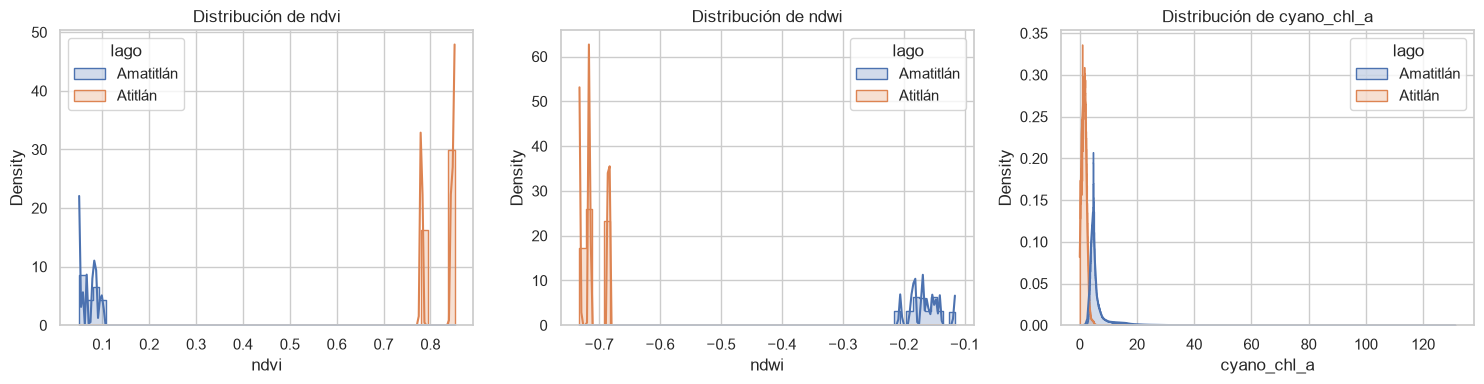

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["ndvi", "ndwi", "cyano_chl_a"]):
    sns.histplot(data=df_ml, x=col, hue="lago", kde=True, ax=ax, element="step", stat="density")
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()


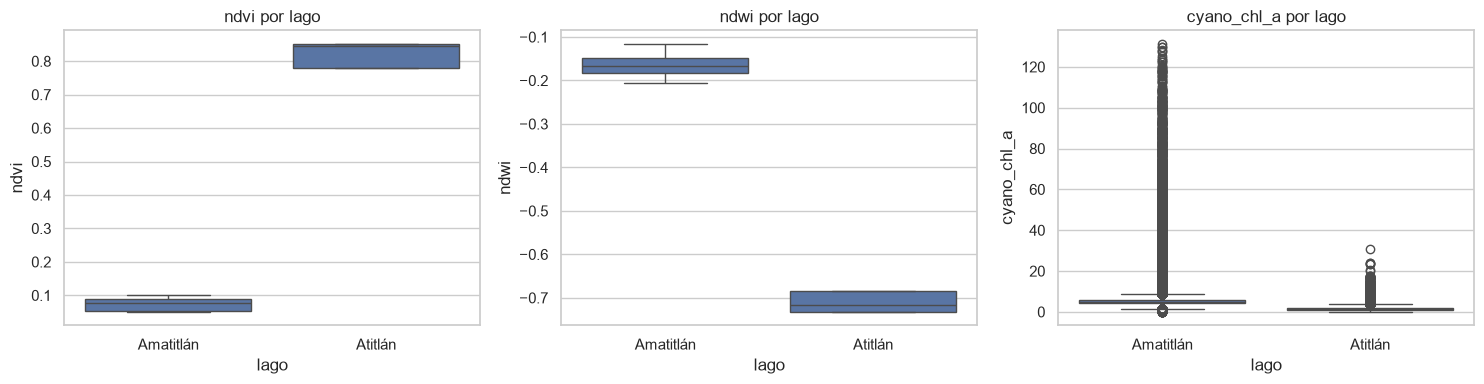

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["ndvi", "ndwi", "cyano_chl_a"]):
    sns.boxplot(data=df_ml, x="lago", y=col, ax=ax)
    ax.set_title(f"{col} por lago")
plt.tight_layout()
plt.show()


In [33]:
df_ml.groupby("lago")[["ndvi", "ndwi", "cyano_chl_a"]].describe().T


lago                   Amatitlán        Atitlán
ndvi        count  402365.000000  781943.000000
            mean        0.073673       0.825189
            std         0.017827       0.032743
            min         0.050568       0.780785
            25%         0.051931       0.780785
            50%         0.077944       0.845433
            75%         0.088136       0.851685
            max         0.100843       0.851685
ndwi        count  402365.000000  781943.000000
            mean       -0.165242      -0.709081
            std         0.023625       0.019334
            min        -0.205490      -0.732344
            25%        -0.182633      -0.732344
            50%        -0.167878      -0.715952
            75%        -0.147873      -0.684300
            max        -0.115819      -0.684300
cyano_chl_a count  402365.000000  781943.000000
            mean        6.289556       1.511161
            std         5.128501       0.876441
            min         0.000348       0.000348
            25%         4.229328       0.852919
            50%         4.756717       1.482144
            75%         6.005022       2.059599
            max       131.243958      30.662933

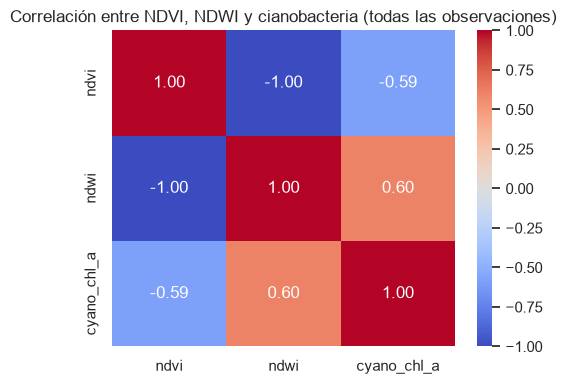

In [34]:
corr = df_ml[["ndvi", "ndwi", "cyano_chl_a"]].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación entre NDVI, NDWI y cianobacteria (todas las observaciones)")
plt.tight_layout()
plt.show()


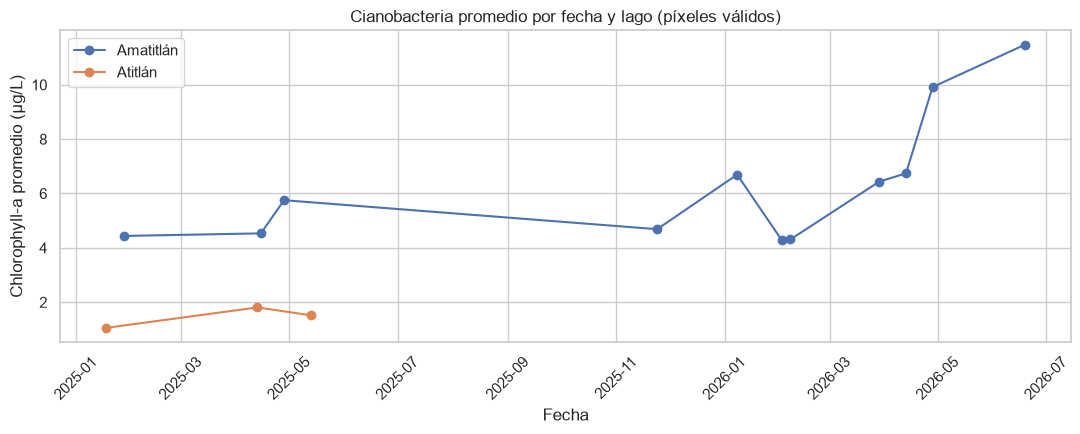

In [35]:
evol = df_ml.groupby(["lago", "fecha"])["cyano_chl_a"].mean().reset_index()

plt.figure(figsize=(11, 4.5))
for lago, grupo in evol.groupby("lago"):
    plt.plot(grupo["fecha"], grupo["cyano_chl_a"], marker="o", label=lago)
plt.ylabel("Chlorophyll-a promedio (µg/L)")
plt.xlabel("Fecha")
plt.title("Cianobacteria promedio por fecha y lago (píxeles válidos)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### 1.6 — Decisiones tomadas durante la preparación y limpieza

- **Grilla de referencia = raster de cianobacteria.** Se usó como base
  porque ya incorpora, dentro del propio *evalscript*, la clasificación
  agua/no-agua (combinando `MNDWI`, `NDWI`, `AWEI`, `NDVI` y un filtro de
  zonas urbanas/suelo desnudo). Reutilizar esa máscara evita duplicar lógica
  de detección de agua y garantiza que cada observación esté dentro del
  cuerpo de agua.
- **Remuestreo por vecino más cercano (nearest neighbor)** para llevar
  `NDVI`/`NDWI` a la grilla de cianobacteria, en lugar de interpolación
  bilineal, para no generar valores espectrales artificiales mezclando
  píxeles con distinta cobertura de nubes.
- **Eliminación de filas con `NaN`** en `ndvi`, `ndwi` o `cyano_chl_a`: estas
  corresponden a bordes de la grilla, nubes u observaciones sin
  correspondencia exacta de fecha entre las fuentes.
- **Filtro de rango físico** de `NDVI`/`NDWI` ([-1, 1]) y de `cyano_chl_a`
  ([0, 500] µg/L) para excluir artefactos numéricos y valores no
  interpretables físicamente, sin recortar agresivamente los verdaderos
  picos de floración (que sí pueden alcanzar decenas de µg/L en ambos
  lagos, como se observó en la Parte I).
- Se conservaron `lat`/`lon` y `fecha` en todo momento, como lo exige el
  enunciado, para poder reconstruir mapas y hacer validación espacial y
  temporal en los siguientes ejercicios.


## 2. Construcción de la variable respuesta

### 2.1 y 2.2 — Definición del punto de corte

El índice de cianobacteria calculado en la Parte I estima la concentración de
**chlorophyll-a en µg/L** a partir del NDCI (`(B05-B04)/(B05+B04)`), usando
el ajuste polinómico de Mishra & Mishra (2012) para estimación de
chlorophyll-a en aguas continentales turbias mediante Sentinel-2/MERIS.

Para definir el punto de corte se usan los **niveles de alerta para
cianobacterias en aguas recreativas** de la OMS (*WHO Guidelines for Safe
Recreational Water Environments*, 2003):

| Nivel | Chlorophyll-a (µg/L) | Densidad de cianobacterias | Riesgo |
|---|---|---|---|
| Vigilancia / bajo | < 10 | < 20 000 cél/mL | Baja probabilidad de efectos adversos |
| **Alerta 1** | **≥ 10** | ≥ 20 000 cél/mL | Probabilidad moderada (irritación de piel/mucosas) |
| Alerta 2 | ≥ 50 | ≥ 100 000 cél/mL o formación de espuma | Alta probabilidad (riesgo agudo a la salud) |

Se utiliza el umbral de **10 µg/L** (equivalente al Nivel de Alerta 1 de la
OMS) como punto de corte para la variable binaria, porque:

- Es un umbral **basado en evidencia epidemiológica** (no arbitrario ni
  dependiente de percentiles de esta muestra particular), lo que permite
  comparar resultados entre lagos y fechas de forma consistente.
- Corresponde al nivel a partir del cual organismos de salud pública
  recomiendan **emitir advertencias** sobre contacto recreativo con el agua,
  que es precisamente el tipo de decisión que un modelo de apoyo al
  monitoreo debería anticipar.
- Es más sensible que el umbral de Alerta 2 (50 µg/L): para un problema de
  salud pública/ambiental es preferible un criterio que capture floraciones
  incipientes ("alta presencia" en un sentido amplio) en vez de solo
  eventos extremos.

*(Bufford et al., 2018 y otras referencias posteriores han propuesto rangos
similares para cianobacterias específicamente; se optó por reportar el
esquema clásico de la OMS 2003 por ser el más citado en la gestión de la
calidad del agua en cuerpos tropicales como Atitlán y Amatitlán.)*


In [36]:
UMBRAL_CHL_A = 10.0  # µg/L — Nivel de Alerta 1, OMS (2003)

df_ml["alta_cianobacteria"] = (df_ml["cyano_chl_a"] >= UMBRAL_CHL_A).astype(int)
df_ml[["cyano_chl_a", "alta_cianobacteria"]].head()


,cyano_chl_a,alta_cianobacteria
0,4.958068,0
1,4.818163,0
2,4.707026,0
3,4.916895,0
4,5.287355,0


### 2.3 — Distribución de la variable respuesta

In [37]:
print("Distribución global:")
print(df_ml["alta_cianobacteria"].value_counts())
print((df_ml["alta_cianobacteria"].value_counts(normalize=True) * 100).round(2))


Distribución global:
alta_cianobacteria
0    1140997
1      43311
Name: count, dtype: int64
alta_cianobacteria
0    96.34
1     3.66
Name: proportion, dtype: float64


In [38]:
dist_lago = pd.crosstab(df_ml["lago"], df_ml["alta_cianobacteria"], normalize="index") * 100
dist_lago.columns = ["% baja/ausente (0)", "% alta (1)"]
print("Distribución por lago (%):")
dist_lago.round(2)


Distribución por lago (%):


,% baja/ausente (0),% alta (1)
lago,,
Amatitlán,89.27,10.73
Atitlán,99.98,0.02


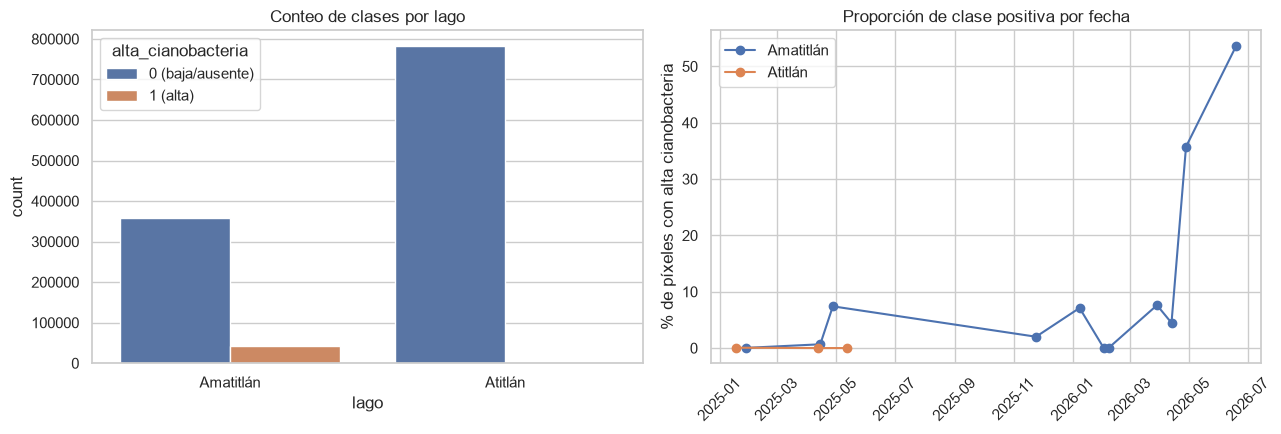

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df_ml, x="lago", hue="alta_cianobacteria", ax=axes[0])
axes[0].set_title("Conteo de clases por lago")
axes[0].legend(title="alta_cianobacteria", labels=["0 (baja/ausente)", "1 (alta)"])

dist_fecha = df_ml.groupby(["lago", "fecha"])["alta_cianobacteria"].mean().reset_index()
for lago, grupo in dist_fecha.groupby("lago"):
    axes[1].plot(grupo["fecha"], grupo["alta_cianobacteria"] * 100, marker="o", label=lago)
axes[1].set_ylabel("% de píxeles con alta cianobacteria")
axes[1].set_title("Proporción de clase positiva por fecha")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### 2.4 — Desbalance de clases

In [40]:
conteo = df_ml["alta_cianobacteria"].value_counts()
ratio = conteo.min() / conteo.max()
print(f"Clase 0 (baja/ausente): {conteo.get(0, 0)}")
print(f"Clase 1 (alta):         {conteo.get(1, 0)}")
print(f"Razón de desbalance (clase minoritaria / clase mayoritaria): {ratio:.3f}")


Clase 0 (baja/ausente): 1140997
Clase 1 (alta):         43311
Razón de desbalance (clase minoritaria / clase mayoritaria): 0.038


Si la proporción entre clases se aleja considerablemente de 1:1 (razón muy
por debajo de ~0.5), existe **desbalance de clases**. Esto tiene las
siguientes consecuencias relevantes para el resto del laboratorio:

- **Entrenamiento:** un clasificador entrenado sin ajustes tenderá a
  favorecer la clase mayoritaria (minimizando el error global) y podría
  volverse poco sensible a detectar la clase minoritaria, que en este caso
  suele ser justamente la de interés (alta presencia de cianobacteria).
  Se puede corregir con `class_weight="balanced"`, sobremuestreo (p. ej.
  SMOTE) o submuestreo, según el modelo.
- **Evaluación:** el **Accuracy** deja de ser una métrica confiable, porque
  un modelo trivial que siempre prediga la clase mayoritaria puede obtener
  un Accuracy alto sin ningún valor práctico. Por eso el enunciado pide
  reportar también **Precision, Recall, F1-score y ROC-AUC**, que son
  sensibles al desbalance y permiten evaluar específicamente qué tan bien
  se detecta la clase de interés (alta presencia).
- Dado el contexto ambiental del problema (Ejercicio 5.3), es probable que
  **Recall de la clase positiva** sea la métrica más relevante, porque un
  falso negativo (no detectar una floración real) tiene consecuencias más
  graves para la salud pública que un falso positivo.


### 2.5 — Variables que no pueden usarse como predictoras

La variable `cyano_chl_a` (chlorophyll-a estimado) fue usada **directamente**
para construir `alta_cianobacteria` (aplicando el umbral de 10 µg/L). Por lo
tanto:

- **`cyano_chl_a` debe excluirse** del conjunto de predictores: incluirla
  causaría fuga de información (*data leakage*), ya que el modelo aprendería
  esencialmente a repetir el umbral de corte en vez de aprender relaciones
  espectrales/geográficas genuinas con la presencia de cianobacteria.
- No se generaron variables *indirectas* derivadas del NDCI (`B05`, `B04`)
  como columnas separadas del dataset, por lo que no hay otras columnas con
  este problema. Si en el futuro se decide incorporar `NDCI` explícitamente
  como variable, este también debería excluirse, porque es la base directa
  del cálculo de `cyano_chl_a`.

En resumen, **`cyano_chl_a` es la única variable que se elimina** del
conjunto de predictores; el resto de variables actuales (`ndvi`, `ndwi`,
`lat`, `lon`, `fecha`, `lago`) se calcularon de forma independiente al
proceso de generación de la variable respuesta y sí pueden utilizarse.


## 3. Selección y construcción de variables predictoras

### 3.1 y 3.2 — Conjunto de variables predictoras

| Variable | Tipo | Corresponde a | Justificación |
|---|---|---|---|
| `ndvi` | índice espectral | banda derivada (B08, B04) | Detecta vegetación/materia orgánica flotante; floraciones algales densas elevan el NDVI del agua por su contenido de pigmentos y biomasa. |
| `ndwi` | índice espectral | banda derivada (B03, B08) | Distingue agua de otras superficies y es sensible a la turbidez/carga de sedimentos y materia en suspensión, asociada a condiciones que favorecen floraciones. |
| `lat`, `lon` | característica espacial | coordenadas | Capturan diferencias espaciales dentro del lago (zonas de descarga de afluentes, bahías con menor circulación, cercanía a fuentes de nutrientes) que no están explícitas en los índices espectrales. |
| `lago` (dummy) | característica espacial/categórica | identificador de cuerpo de agua | Atitlán y Amatitlán tienen morfometría, profundidad y niveles de eutrofización muy distintos; permite que el modelo aprenda diferencias sistémicas entre ambos. |
| `mes` | temporal | fecha de adquisición | La temperatura y la estacionalidad de lluvias en Guatemala (época seca: nov–abr; lluviosa: may–oct) modulan la estratificación térmica y el aporte de nutrientes por escorrentía, factores clave para floraciones. |
| `dia_anio` | temporal | fecha de adquisición | Captura estacionalidad de forma continua (alternativa/complemento a `mes`), útil para modelos que aprovechan variables numéricas cíclicas. |
| `dist_orilla_m` | característica espacial (ingeniería) | distancia al polígono del lago | Las zonas cercanas a la orilla suelen tener aguas más someras, mayor temperatura y mayor acumulación de nutrientes por escorrentía; se espera mayor probabilidad de floración cerca de la costa. |

### 3.3 — Ingeniería de características

Se construyen dos variables adicionales, ambas justificadas arriba:

- **`dist_orilla_m`**: distancia en metros desde cada observación hasta el
  borde del polígono del lago (`lago_<nombre>.geojson`), calculada
  reproyectando a `EPSG:32615` (mismo CRS métrico que se usará en la
  validación espacial del Ejercicio 6) para obtener una distancia en metros
  correcta.
- **`mes`** y **`dia_anio`**: derivadas directamente de `fecha`, sin
  necesidad de descargar información adicional, para representar
  estacionalidad.

No se incluyen bandas espectrales crudas adicionales (p. ej. `B11`, `B12`)
porque la Parte I no las descargó como raster independiente; si se decide
incorporarlas más adelante, deberán obtenerse con el mismo pipeline de
`openEO` usado para `NDVI`/`NDWI` y remuestrearse con el mismo procedimiento
de vecino más cercano descrito en la sección 1.


In [41]:
import json
with open("lago_atitlan.geojson") as f:
    gj = json.load(f)
print(gj.get("type"), list(gj.keys()))

Feature ['type', 'properties', 'geometry']


In [46]:
def distancia_a_orilla(df, lago_nombre, ruta_geojson):
    sub = df[df["lago"] == lago_nombre]
    if sub.empty or not os.path.exists(ruta_geojson):
        print(f"[AVISO] No se pudo calcular distancia a la orilla para {lago_nombre} "
              f"(archivo {ruta_geojson} no encontrado).")
        return pd.Series(np.nan, index=sub.index)

    with open(ruta_geojson, "r", encoding="utf-8") as f:
        gj = json.load(f)

    # El geojson puede venir como FeatureCollection, Feature suelto,
    # o directamente una geometría (Polygon/MultiPolygon)
    tipo = gj.get("type")
    if tipo == "FeatureCollection":
        gdf_lago = gpd.GeoDataFrame.from_features(gj["features"], crs=CRS_GEOGRAFICO)
    elif tipo == "Feature":
        gdf_lago = gpd.GeoDataFrame.from_features([gj], crs=CRS_GEOGRAFICO)
    else:
        # geometría "pelada": Polygon, MultiPolygon, etc.
        from shapely.geometry import shape
        gdf_lago = gpd.GeoDataFrame(geometry=[shape(gj)], crs=CRS_GEOGRAFICO)

    poligono_utm = gdf_lago.to_crs(CRS_METRICO).union_all()
    borde_utm = poligono_utm.boundary

    puntos = gpd.GeoDataFrame(
        geometry=[Point(xy) for xy in zip(sub["lon"], sub["lat"])],
        index=sub.index, crs=CRS_GEOGRAFICO
    ).to_crs(CRS_METRICO)

    return puntos.geometry.distance(borde_utm)

In [47]:
import inspect
print(inspect.getsource(distancia_a_orilla))

def distancia_a_orilla(df, lago_nombre, ruta_geojson):
    sub = df[df["lago"] == lago_nombre]
    if sub.empty or not os.path.exists(ruta_geojson):
        print(f"[AVISO] No se pudo calcular distancia a la orilla para {lago_nombre} "
              f"(archivo {ruta_geojson} no encontrado).")
        return pd.Series(np.nan, index=sub.index)

    with open(ruta_geojson, "r", encoding="utf-8") as f:
        gj = json.load(f)

    # El geojson puede venir como FeatureCollection, Feature suelto,
    # o directamente una geometría (Polygon/MultiPolygon)
    tipo = gj.get("type")
    if tipo == "FeatureCollection":
        gdf_lago = gpd.GeoDataFrame.from_features(gj["features"], crs=CRS_GEOGRAFICO)
    elif tipo == "Feature":
        gdf_lago = gpd.GeoDataFrame.from_features([gj], crs=CRS_GEOGRAFICO)
    else:
        # geometría "pelada": Polygon, MultiPolygon, etc.
        from shapely.geometry import shape
        gdf_lago = gpd.GeoDataFrame(geometry=[shape(gj)], crs=CRS_GEOGRAFICO)

  

In [44]:
print(df_ml.columns.tolist())

['lago', 'fecha', 'lat', 'lon', 'ndvi', 'ndwi', 'cyano_chl_a', 'alta_cianobacteria']


In [45]:
distancias = []
for lago in LAGOS_BBOX:
    slug = LAGOS_SLUG[lago]
    distancias.append(distancia_a_orilla(df_ml, lago, f"lago_{slug}.geojson"))

df_ml["dist_orilla_m"] = pd.concat(distancias).reindex(df_ml.index)

df_ml["mes"] = df_ml["fecha"].dt.month
df_ml["dia_anio"] = df_ml["fecha"].dt.dayofyear

df_ml[["lago", "fecha", "ndvi", "ndwi", "dist_orilla_m", "mes", "dia_anio"]].head()

,lago,fecha,ndvi,ndwi,dist_orilla_m,mes,dia_anio
0,Amatitlán,2025-01-28,0.096486,-0.182633,296.577359,1,28
1,Amatitlán,2025-01-28,0.096486,-0.182633,296.580402,1,28
2,Amatitlán,2025-01-28,0.096486,-0.182633,296.583429,1,28
3,Amatitlán,2025-01-28,0.096486,-0.182633,296.586439,1,28
4,Amatitlán,2025-01-28,0.096486,-0.182633,296.589433,1,28


In [48]:
PREDICTORES = ["ndvi", "ndwi", "lat", "lon", "dist_orilla_m", "mes", "dia_anio", "lago"]
VARIABLE_RESPUESTA = "alta_cianobacteria"
EXCLUIDA_POR_FUGA = ["cyano_chl_a"]  # ver Ejercicio 2.5

df_final = df_ml[["lago", "fecha", "lat", "lon"] +
                  ["ndvi", "ndwi", "dist_orilla_m", "mes", "dia_anio"] +
                  ["cyano_chl_a", VARIABLE_RESPUESTA]].copy()

print("Dimensiones del conjunto final:", df_final.shape)
print("\nPredictores seleccionados:", PREDICTORES)
print("Variable respuesta:", VARIABLE_RESPUESTA)
print("Excluida por posible fuga de información:", EXCLUIDA_POR_FUGA)

df_final.describe(include="all").T


Dimensiones del conjunto final: (1184308, 11)

Predictores seleccionados: ['ndvi', 'ndwi', 'lat', 'lon', 'dist_orilla_m', 'mes', 'dia_anio', 'lago']
Variable respuesta: alta_cianobacteria
Excluida por posible fuga de información: ['cyano_chl_a']


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
lago,1184308,2,Atitlán,781943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,1184308,NaN,NaN,NaN,2025-06-23 09:57:27.331606272,2025-01-18 00:00:00,2025-04-13 00:00:00,2025-04-28 00:00:00,2025-05-13 00:00:00,2026-06-19 00:00:00,NaN
lat,1184308.0,NaN,NaN,NaN,14.613932,14.412347,14.475798,14.678072,14.704697,14.750979,0.115422
lon,1184308.0,NaN,NaN,NaN,-90.981324,-91.323081,-91.213264,-91.155741,-90.583257,-90.512924,0.299613
ndvi,1184308.0,NaN,NaN,NaN,0.569864,0.050568,0.088136,0.780785,0.851685,0.851685,0.35708
ndwi,1184308.0,NaN,NaN,NaN,-0.524313,-0.732344,-0.715952,-0.6843,-0.182633,-0.115819,0.258421
dist_orilla_m,1184308.0,NaN,NaN,NaN,4349.857762,0.001174,2515.043914,4043.608759,6192.883885,8637.682775,2201.212956
mes,1184308.0,NaN,NaN,NaN,3.657791,1.0,2.0,4.0,5.0,11.0,2.032719
dia_anio,1184308.0,NaN,NaN,NaN,95.555646,8.0,33.0,103.0,133.0,328.0,62.072299
cyano_chl_a,1184308.0,NaN,NaN,NaN,3.134606,0.000348,1.18927,2.076014,4.307852,131.243958,3.816401


In [49]:
os.makedirs("data/processed", exist_ok=True)
df_final.to_csv("data/processed/dataset_ml_cianobacteria.csv", index=False)
print("Conjunto de datos guardado en data/processed/dataset_ml_cianobacteria.csv")


Conjunto de datos guardado en data/processed/dataset_ml_cianobacteria.csv


### Siguientes pasos

Con `df_final` (incluyendo `cyano_chl_a` únicamente como referencia, **no**
como predictor) queda listo el conjunto de datos para continuar con el
**Ejercicio 4 — Construcción de modelos de Machine Learning** (Regresión
Logística, Random Forest y Gradient Boosting/XGBoost), la validación
espacial (Ejercicio 6) y la generalización entre lagos (Ejercicio 7) en la
siguiente entrega.
